In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
k_values = [1, 3, 5, 7, 9, 11, 13, 15]
distance_functions = ["euclidean", "manhattan", "minkowski"]
datasets = ["bc",  "hp", "hp_imp"]

df_test = pd.read_csv("./knn_metrics.csv")
df_train = pd.read_csv("./knn_metrics_train.csv")
df_test.head()

,dataset,distance_function,k_value,accuracy,precision,sensitivity,specificity,false_positive_rate,f1
0,bc,euclidean,1,0.938053,0.925000,0.902439,0.958333,0.041667,0.913580
1,bc,euclidean,3,0.929204,0.923077,0.878049,0.958333,0.041667,0.900000
2,bc,euclidean,5,0.938053,0.947368,0.878049,0.972222,0.027778,0.911392
3,bc,euclidean,7,0.938053,0.947368,0.878049,0.972222,0.027778,0.911392
4,bc,euclidean,9,0.938053,0.947368,0.878049,0.972222,0.027778,0.911392


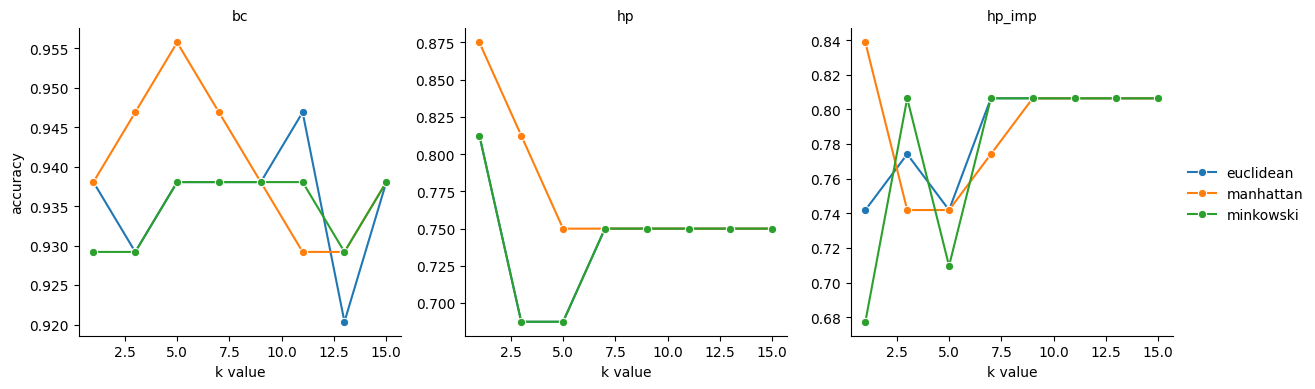

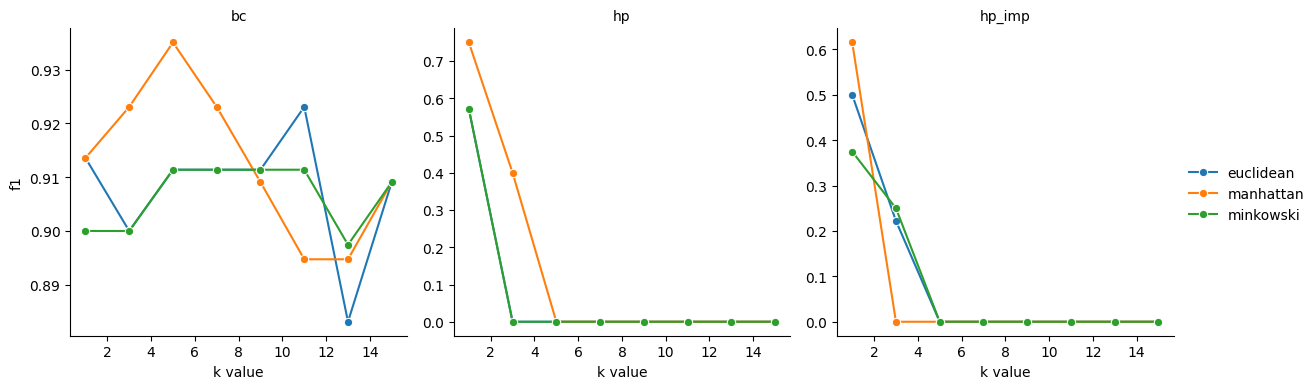

In [25]:
metrics_to_plot = ["accuracy", "f1"]

for metric in metrics_to_plot:
    g = sns.FacetGrid(df_test, col="dataset", height=4, sharey=False)
    g.map_dataframe(
        sns.lineplot,
        x="k_value",
        y=metric,
        hue="distance_function",
        marker="o"
    )
    g.add_legend()
    g.set_axis_labels("k value", metric)
    g.set_titles("{col_name}")
    plt.show()

In [26]:
def get_dataset_name(dataset):
    if dataset == "bc":
        return "Breast Cancer"
    elif dataset == "hp":
        return "Hepatitis"
    else:
        return "Hepatitis (Imputed)"

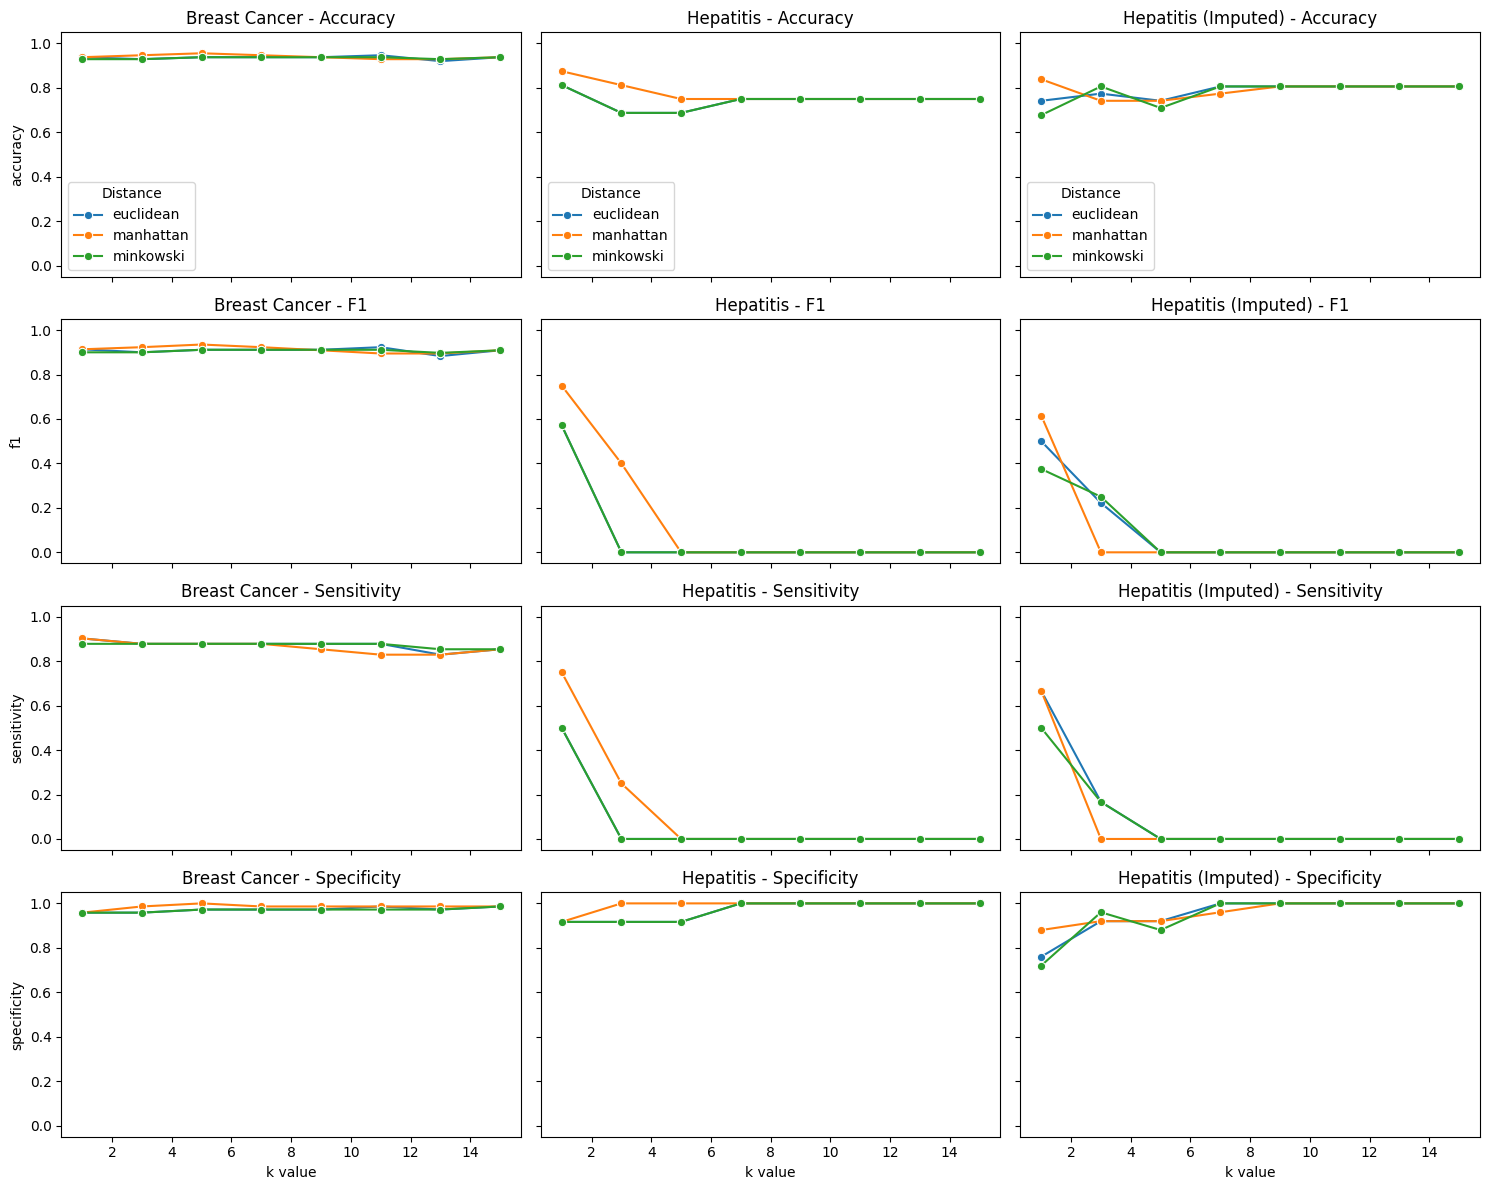

In [27]:
metrics_to_plot = ["accuracy", "f1", "sensitivity", "specificity"]
fig, axes = plt.subplots(len(metrics_to_plot), 3, figsize=(15, 12), sharex=True, sharey=True)
datasets = df_test["dataset"].unique()

for i, metric in enumerate(metrics_to_plot):
    for j, dataset in enumerate(datasets):
        ax = axes[i, j]
        subset = df_test[df_test["dataset"] == dataset]
        sns.lineplot(
            data=subset, # type: ignore
            x="k_value",
            y=metric,
            hue="distance_function",
            marker="o",
            ax=ax
        )
        ax.set_title(f"{get_dataset_name(dataset)} - {metric.title()}")
        if i == len(metrics_to_plot)-1:
            ax.set_xlabel("k value")
        else:
            ax.set_xlabel("")
        if j == 0:
            ax.set_ylabel(metric)
        else:
            ax.set_ylabel("")
        if i == 0:
            ax.legend(title="Distance")
        else:
            ax.get_legend().remove()
plt.tight_layout()
plt.show()

In [28]:
best_bc_model = df_test[
    (df_test["dataset"] == "bc") &
    (df_test["distance_function"] == "manhattan") &
    (df_test["k_value"] == 7)
]
best_bc_model

,dataset,distance_function,k_value,accuracy,precision,sensitivity,specificity,false_positive_rate,f1
11,bc,manhattan,7,0.946903,0.972973,0.878049,0.986111,0.013889,0.923077


In [29]:
best_hp_model = df_test[
    (df_test["dataset"] == "hp") &
    (df_test["distance_function"] == "minkowski") &
    (df_test["k_value"] == 3)
]
best_hp_model

,dataset,distance_function,k_value,accuracy,precision,sensitivity,specificity,false_positive_rate,f1
41,hp,minkowski,3,0.6875,0.0,0.0,0.916667,0.083333,0.0


In [30]:
best_hp_imp_model = df_test[
    (df_test["dataset"] == "hp_imp") &
    (df_test["distance_function"] == "euclidean") &
    (df_test["k_value"] == 1)
]
best_hp_imp_model

,dataset,distance_function,k_value,accuracy,precision,sensitivity,specificity,false_positive_rate,f1
48,hp_imp,euclidean,1,0.741935,0.4,0.666667,0.76,0.24,0.5


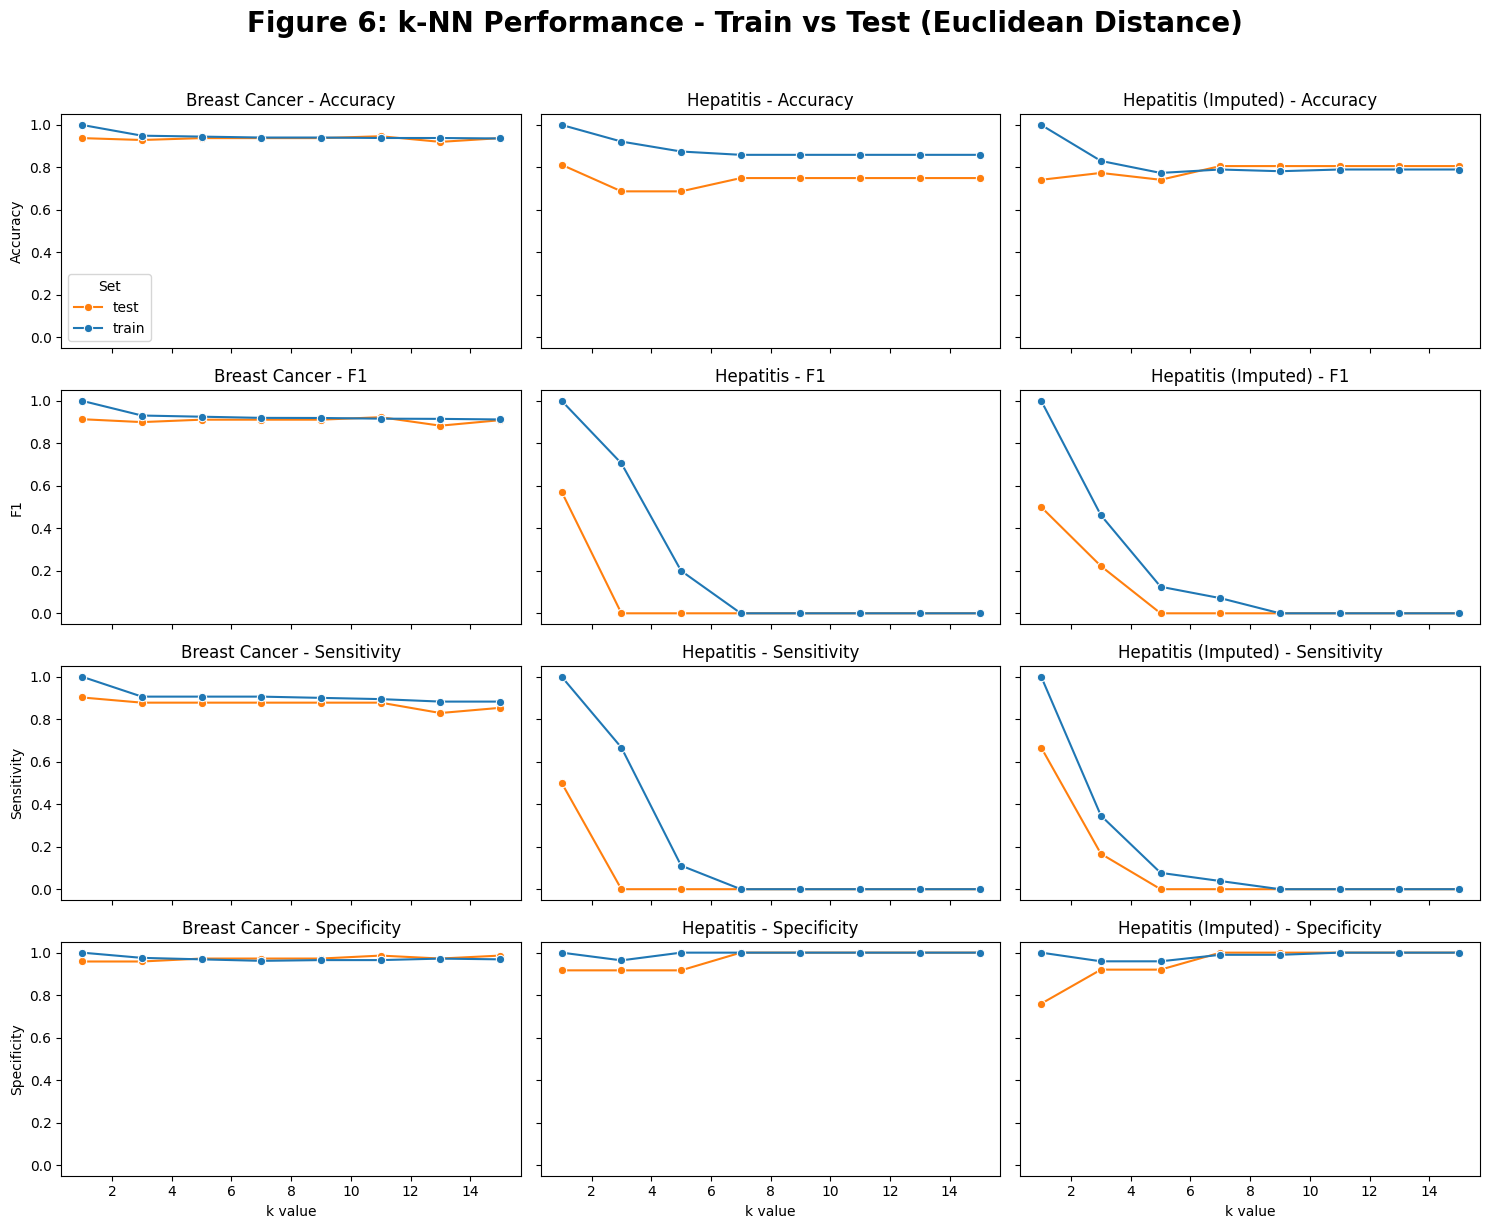

In [ ]:
# 1. Setup the combined data
df_test['set'] = 'test'
df_train['set'] = 'train'
df_plot_combined = pd.concat([df_test, df_train], ignore_index=True)

# 2. Define the distances to iterate through
target_distances = ["euclidean", "manhattan", "minkowski"]
metrics_to_plot = ["accuracy", "f1", "sensitivity", "specificity"]
datasets = df_plot_combined["dataset"].unique()

# 3. Outer loop to create a NEW figure for each distance
for dist in target_distances:
    fig, axes = plt.subplots(len(metrics_to_plot), 3, figsize=(15, 12), sharex=True, sharey=True)
    
    for i, metric in enumerate(metrics_to_plot):
        for j, dataset in enumerate(datasets):
            ax = axes[i, j]
            
            # Filter using the current 'dist' string
            subset = df_plot_combined[
                (df_plot_combined["dataset"] == dataset) & 
                (df_plot_combined["distance_function"] == dist)
            ]
            
            sns.lineplot(
                data=subset,
                x="k_value",
                y=metric,
                hue="set",
                marker="o",
                ax=ax,
                palette={"train": "tab:blue", "test": "tab:orange"} 
            )
            
            # Title handling
            try:
                ax.set_title(f"{get_dataset_name(dataset)} - {metric.title()}")
            except NameError:
                ax.set_title(f"{dataset} - {metric.title()}")
            
            # Axes Formatting
            if i == len(metrics_to_plot) - 1:
                ax.set_xlabel("k value")
            else:
                ax.set_xlabel("")
                
            if j == 0:
                ax.set_ylabel(metric.title())
            else:
                ax.set_ylabel("")
                
            # Legend Management
            if i == 0 and j == 0:
                ax.legend(title="Set", loc="lower left")
            else:
                legend = ax.get_legend()
                if legend:
                    legend.remove()

    # Dynamic Super Title for each specific grid
    plt.suptitle(f"Figure 6: k-NN Performance - Train vs Test ({dist.title()} Distance)", 
                 fontsize=20, y=1.02, fontweight='bold')
    
    plt.tight_layout()
    
    # Optional: Save each one automatically so you can grab them for your report
    plt.savefig(f"knn_metrics_{dist}.png", bbox_inches='tight')
    plt.show()